# Unistroke Gesture Recognizers

This notebook uses the XML gesture logs in `xml_logs`. It trains three small LSTM models and compares them with the `$1` recognizer. The test set has 10 samples per gesture class.

## Implementation Scope

- Load XML gestures from `xml_logs`.
- Get labels from filenames and folders.
- Convert each gesture to a fixed `(64, 2)` sequence.
- Use Keras `to_categorical` for one-hot labels.
- Train one larger LSTM and two smaller LSTMs.
- Compare accuracy and prediction time with `$1`.

In [1]:
from pathlib import Path
import os
import random
import time

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", str(Path("tmp/matplotlib").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

from matplotlib import pyplot as plt
import numpy as np

from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Input, LSTM
from keras.models import Sequential
from keras.utils import set_random_seed, to_categorical

from recognizer import (
    ALL_GESTURES,
    DollarRecognizer,
    create_test_dataset,
    display_label,
    group_gesture_files,
    label_from_path,
    normalize_points,
    read_xml_points,
)

SEED = 6
NUM_POINTS = 64
LOG_DIR = Path("xml_logs")
TEST_DIR = Path("datasets/unistroke_test")

random.seed(SEED)
np.random.seed(SEED)
set_random_seed(SEED)

print(f"NumPy seed: {SEED}")

NumPy seed: 6


## Read Data

The data comes from `xml_logs`. The helper functions in `recognizer.py` read XML files and labels, so the notebook and apps use the same code.

In [2]:
grouped = group_gesture_files(LOG_DIR, ALL_GESTURES)
total_files = sum(len(files) for files in grouped.values())

print(f"classes: {len(grouped)}")
print(f"files:   {total_files}")
for label, files in grouped.items():
    print(f"{label:18s} {len(files):3d}")

classes: 16
files:   5280
arrow              330
caret              330
check              330
circle             330
delete_mark        330
left_curly_brace   330
left_sq_bracket    330
pigtail            330
question_mark      330
rectangle          330
right_curly_brace  330
right_sq_bracket   330
star               330
triangle           330
v                  330
x                  330


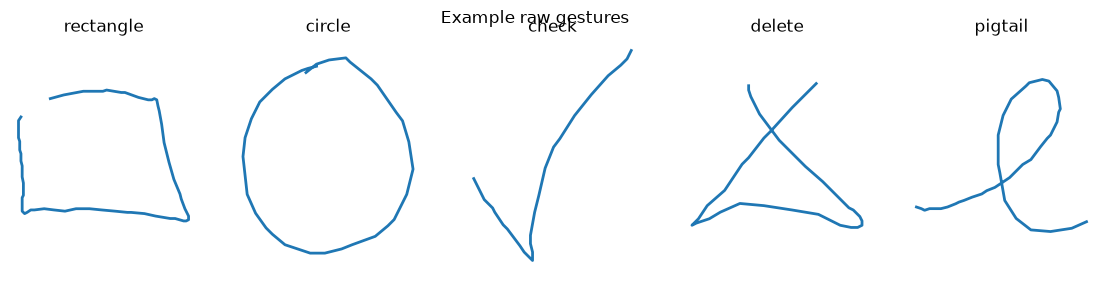

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for axis, label in zip(axes, ["rectangle", "circle", "check", "delete_mark", "pigtail"]):
    points = np.array(read_xml_points(grouped[label][0]))
    axis.plot(points[:, 0], -points[:, 1], linewidth=2)
    axis.set_title(display_label(label))
    axis.axis("equal")
    axis.axis("off")
plt.suptitle("Example raw gestures")
plt.show()

## Create the Required Test Dataset

I copy the first 10 sorted XML files from each class into `datasets/unistroke_test`. These files are kept out of training.

In [4]:
created = create_test_dataset(
    log_dir=LOG_DIR,
    output_dir=TEST_DIR,
    samples_per_class=10,
    labels=ALL_GESTURES,
)

test_source_files = {
    path
    for label in ALL_GESTURES
    for path in grouped[label][:10]
}
train_files = [
    path
    for label in ALL_GESTURES
    for path in grouped[label]
    if path not in test_source_files
]
test_files = sorted(test_source_files)
copied_test_files = sorted(TEST_DIR.glob("*/*.xml"))

print(f"created test XMLs: {sum(len(paths) for paths in created.values())}")
print(f"copied test XMLs:  {len(copied_test_files)}")
print(f"training XMLs:     {len(train_files)}")
print(f"test XMLs:         {len(test_files)}")
print(f"first copied label: {label_from_path(copied_test_files[0])}")

created test XMLs: 160
copied test XMLs:  160
training XMLs:     5120
test XMLs:         160
first copied label: arrow


## Prepare Data

The LSTM needs the same input size for every gesture. I use the `$1` 64-point normalization, so each gesture becomes a `(64, 2)` array.

In [5]:
def prepare_sequence(points, num_points=NUM_POINTS):
    if num_points != NUM_POINTS:
        raise ValueError("This notebook uses the recognizer's 64-point normalization.")
    return np.array(normalize_points(points), dtype=np.float32)


def stratified_validation_split(files, validation_fraction=0.15):
    rng = np.random.default_rng(SEED)
    files_by_label = {label: [] for label in labels}
    for path in sorted(files):
        files_by_label[label_from_path(path)].append(path)

    model_files = []
    validation_files = []
    for label in labels:
        label_files = files_by_label[label]
        if len(label_files) < 2:
            raise ValueError(f"Need at least 2 training files for {label}.")

        indices = np.arange(len(label_files))
        rng.shuffle(indices)
        validation_count = max(1, int(round(len(label_files) * validation_fraction)))
        validation_count = min(validation_count, len(label_files) - 1)
        validation_indices = set(indices[:validation_count].tolist())

        for index, file_path in enumerate(label_files):
            if index in validation_indices:
                validation_files.append(file_path)
            else:
                model_files.append(file_path)

    return sorted(model_files), sorted(validation_files)


labels = list(ALL_GESTURES)
label_to_index = {label: index for index, label in enumerate(labels)}
model_train_files, validation_files = stratified_validation_split(train_files)

X_train = np.array([prepare_sequence(read_xml_points(path)) for path in model_train_files])
X_val = np.array([prepare_sequence(read_xml_points(path)) for path in validation_files])
X_test = np.array([prepare_sequence(read_xml_points(path)) for path in test_files])
y_train_labels = np.array([label_from_path(path) for path in model_train_files])
y_val_labels = np.array([label_from_path(path) for path in validation_files])
y_test_labels = np.array([label_from_path(path) for path in test_files])

y_train_indices = np.array([label_to_index[label] for label in y_train_labels])
y_val_indices = np.array([label_to_index[label] for label in y_val_labels])
y_test_indices = np.array([label_to_index[label] for label in y_test_labels])
y_train = to_categorical(y_train_indices, num_classes=len(labels))
y_val = to_categorical(y_val_indices, num_classes=len(labels))
y_test = to_categorical(y_test_indices, num_classes=len(labels))

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)


X_train: (4352, 64, 2)
X_val:   (768, 64, 2)
X_test:  (160, 64, 2)
y_train: (4352, 16)
y_val:   (768, 16)
y_test:  (160, 16)


## Define and Train Model

The main model is `Input((NUM_POINTS, 2)) -> LSTM(64) -> Dense(32) -> softmax`. The other two models use fewer units.

In [6]:
MODEL_SPECS = [
    {"name": "lstm_64_dense32", "lstm_units": 64, "dense_units": 32},
    {"name": "lstm_32_dense16", "lstm_units": 32, "dense_units": 16},
    {"name": "lstm_16_dense8", "lstm_units": 16, "dense_units": 8},
]


def build_lstm_model(spec, num_classes):
    model = Sequential(name=spec["name"])
    model.add(Input((NUM_POINTS, 2)))
    model.add(LSTM(spec["lstm_units"]))
    model.add(Dense(spec["dense_units"], activation="relu"))
    model.add(Dense(num_classes, activation="softmax"))
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

## Train LSTM Variants

All variants use the same deterministic stratified train/validation split. The copied test set is only used for the final results.


In [7]:
comparison_results = []
histories = {}
for spec in MODEL_SPECS:
    print(f"Training {spec['name']}...")
    model = build_lstm_model(spec, len(labels))
    callbacks = [
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=0.0001),
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ]
    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, y_val),
        shuffle=True,
        verbose=0,
        callbacks=callbacks,
    )

    model(X_test[:1], training=False).numpy()
    start = time.perf_counter()
    probabilities = model(X_test, training=False).numpy()
    mean_time = (time.perf_counter() - start) / len(X_test)
    predicted_indices = np.argmax(probabilities, axis=1)
    accuracy = np.mean(predicted_indices == y_test_indices)

    histories[spec["name"]] = history.history
    comparison_results.append(
        {
            "name": spec["name"],
            "kind": "LSTM",
            "parameters": model.count_params(),
            "templates": 0,
            "accuracy": float(accuracy),
            "mean_prediction_ms": mean_time * 1000,
        }
    )
    print(
        f"{spec['name']}: params={model.count_params()}, "
        f"accuracy={accuracy:.3f}, prediction={mean_time * 1000:.3f} ms"
    )


Training lstm_64_dense32...


lstm_64_dense32: params=19760, accuracy=1.000, prediction=0.862 ms
Training lstm_32_dense16...


lstm_32_dense16: params=5280, accuracy=0.988, prediction=0.855 ms
Training lstm_16_dense8...


lstm_16_dense8: params=1496, accuracy=0.838, prediction=0.828 ms


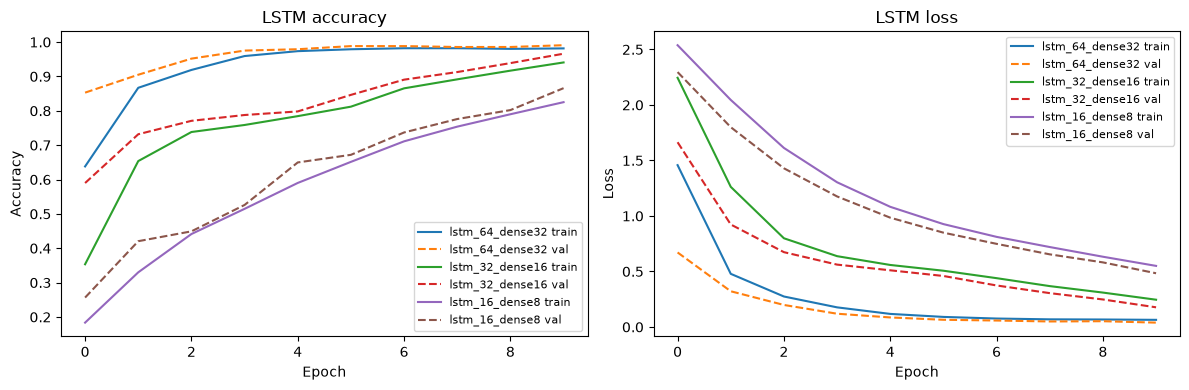

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history in histories.items():
    axes[0].plot(history["accuracy"], label=f"{name} train")
    axes[0].plot(history["val_accuracy"], linestyle="--", label=f"{name} val")
    axes[1].plot(history["loss"], label=f"{name} train")
    axes[1].plot(history["val_loss"], linestyle="--", label=f"{name} val")

axes[0].set_title("LSTM accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8)
axes[1].set_title("LSTM loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Assignment Extension: Compare with the `$1` Recognizer

The `$1` recognizer uses templates from the training files. It is tested on the same files as the LSTM models.

In [9]:
def build_dollar_from_files(files, templates_per_label=10):
    recognizer = DollarRecognizer()
    files_by_label = {label: [] for label in labels}
    for path in sorted(files):
        files_by_label[label_from_path(path)].append(path)

    for label in labels:
        for path in files_by_label[label][:templates_per_label]:
            recognizer.add_template(label, read_xml_points(path))
    return recognizer


dollar_recognizer = build_dollar_from_files(train_files, templates_per_label=10)
test_point_lists = [read_xml_points(path) for path in test_files]

start = time.perf_counter()
dollar_predictions = [dollar_recognizer.recognize(points)[0] for points in test_point_lists]
dollar_elapsed = time.perf_counter() - start
dollar_accuracy = np.mean(dollar_predictions == y_test_labels)

comparison_results.append(
    {
        "name": "$1 recognizer",
        "kind": "$1",
        "parameters": 0,
        "templates": len(dollar_recognizer.templates),
        "accuracy": float(dollar_accuracy),
        "mean_prediction_ms": (dollar_elapsed / len(test_point_lists)) * 1000,
    }
)

print(f"templates: {len(dollar_recognizer.templates)}")
print(f"accuracy:  {dollar_accuracy:.3f}")
print(f"prediction: {(dollar_elapsed / len(test_point_lists)) * 1000:.3f} ms")

templates: 160
accuracy:  1.000
prediction: 44.599 ms


## Results

The table and plots compare accuracy, prediction time, LSTM parameters, and `$1` templates.

In [10]:
header = f"{'method':18s} {'kind':6s} {'params':>8s} {'templates':>9s} {'accuracy':>9s} {'pred ms':>9s}"
print(header)
print("-" * len(header))
for row in comparison_results:
    print(
        f"{row['name']:18s} {row['kind']:6s} {row['parameters']:8d} "
        f"{row['templates']:9d} {row['accuracy']:9.3f} {row['mean_prediction_ms']:9.3f}"
    )

method             kind     params templates  accuracy   pred ms
----------------------------------------------------------------
lstm_64_dense32    LSTM      19760         0     1.000     0.862
lstm_32_dense16    LSTM       5280         0     0.988     0.855
lstm_16_dense8     LSTM       1496         0     0.838     0.828
$1 recognizer      $1            0       160     1.000    44.599


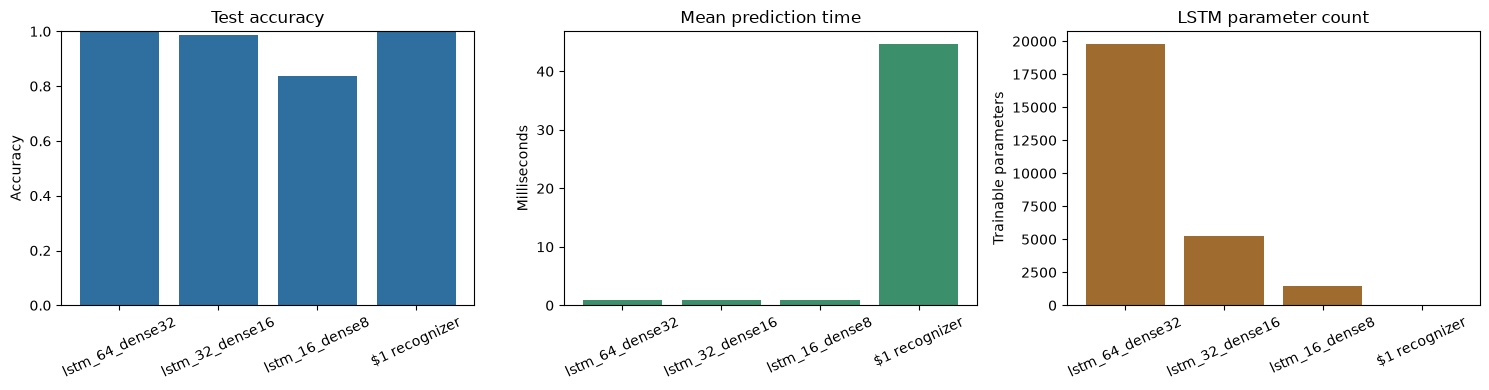

In [11]:
names = [row["name"] for row in comparison_results]
accuracies = [row["accuracy"] for row in comparison_results]
prediction_times = [row["mean_prediction_ms"] for row in comparison_results]
parameters = [row["parameters"] for row in comparison_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(names, accuracies, color="#2f6f9f")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Test accuracy")

axes[1].bar(names, prediction_times, color="#3b8f6b")
axes[1].set_ylabel("Milliseconds")
axes[1].set_title("Mean prediction time")

axes[2].bar(names, parameters, color="#9f6b2f")
axes[2].set_ylabel("Trainable parameters")
axes[2].set_title("LSTM parameter count")

for axis in axes:
    axis.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

In [12]:
best_accuracy = max(row["accuracy"] for row in comparison_results)
best_accuracy_rows = [
    row for row in comparison_results if abs(row["accuracy"] - best_accuracy) < 1e-12
]
dollar_row = next(row for row in comparison_results if row["kind"] == "$1")
best_names = ", ".join(row["name"] for row in best_accuracy_rows)

print(f"Best accuracy: {best_names} ({best_accuracy:.3f})")
print(f"My choice: {dollar_row['name']} ({dollar_row['accuracy']:.3f})")
print("Reason: I would use $1 for the app because it matched the best accuracy here and does not need training.")


Best accuracy: lstm_64_dense32, $1 recognizer (1.000)
My choice: $1 recognizer (1.000)
Reason: I would use $1 for the app because it matched the best accuracy here and does not need training.


## Conclusion

The largest LSTM and `$1` recognizer tied for best accuracy on this fixed split. Smaller LSTMs use fewer parameters but were less accurate here. `$1` was slower, but it needs no training and is easier to debug, so I would still use `$1` in the app. This is not a general 100% accuracy claim for new users.
